# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Train and Test](#Train_and_Test)
- [3. Feature Selection](#Feature_Selection)
- [4. Model](#Model)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

pip install lifelines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, StandardScaler
from lifelines import CoxPHFitter

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [2]:
#Alano
file_path = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\Preprocessed_dataset_BNP_teste_alano.csv"
BNP = pd.read_csv(file_path)

**METADATA:**
- DOSSIER
- is_san
- is_sol
- DCREAT
- DCRD_0
- CLOSE_DATE
- DURDEG
- RANGPRO-max
- RANGCLI_max
- delay-sum
- MENSALIDADE
- CRD_min
- MTFINO
- RESSO_mean
- RISKA_mean
- NBENF_mean
- RN_mean
- SREC
- PRODALP
- AGFIN
- PAGAMENTO
- CSP
- NATIO
- PTT
- MODCONTACTO
- NEXT_DOSSIER_DATE
- DAYS_TO_NEXT
- CHURN
- OBS_END_DATE
- DOSSIER_DURATION_DAYS
- N_PREVIOUS_DOSSIERS
- AVG_DURATION
- previous_churn_rate
- time_between_dossiers
- count_cl_mean
- montvenc_cl_mean
- montabatv_cl_mean
- dividas_cl_mean
- subcount_total_mean
- montenc_total_mean
- montabatv_totall_mean
- dividas_total_mean
- HIGH_RISK_CURRENT
- ks_score_tier
- is_risky
- ALLBD_mean_lifecycle_CL_N
- ALLBD_N_events_N
- sdem_SITFAM
- sdem_HABITAT
- sdem_age
- active_credit_ratio

In [3]:
# mostrar todas as colunas
pd.set_option('display.max_columns', None)

# mostrar toda a largura da tabela
pd.set_option('display.width', None)

# mostrar todo o conteúdo das células
pd.set_option('display.max_colwidth', None)

In [4]:
BNP = BNP.drop(columns='TIME_MONTHS')
BNP

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,time_to_churn,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,1,0,2024-06-25,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.993500,0.000000,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,1.0,17,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,1,0,2024-09-13,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.466000,0.000000,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,1.0,17,2025-11-30,443,1,97.0,-1.0,80.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
2,0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43,0,0,2018-03-29,NaN,120,91,91,0,347.447280,8115.247,20000.00,1113.258000,0.000000,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaN,92,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.000,0.0,26448.0320,9.72,0.000,0.0,34000.1492,0.0,D,1.0,False,120.0,0.675000,10.0,C,P,52.0,0.090909
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,796b87efb05b1ec3f822189b7b5fe25be06390e7462d228bc34ef083de72f011,0,1,2001-09-21,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.483000,0.000000,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,1.0,270,2024-03-31,8227,0,-1.0,-1.0,-1.0,1.32,0.000,0.0,7120.2352,5.20,0.000,0.0,26643.3160,0.0,Unknown,1.0,1.0,60.0,0.178571,8.0,C,A,44.0,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c,0,1,2001-09-27,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.483000,0.000000,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,1.0,270,2024-03-31,8221,1,8227.0,-1.0,6.0,1.32,0.000,0.0,7120.2352,5.20,0.000,0.0,26643.3160,0.0,Unknown,1.0,1.0,60.0,0.178571,8.0,C,A,44.0,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea71582af5034c1e9a250,0,1,2021-02-12,2024-01-31,34,34,34,0,57.095138,0.000,1500.00,896.196000,0.000000,1.0,0.0,0.000000,P,EP,118.0,P,80,P,4400,W,1.0,35,2024-01-31,1083,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,106.0964,2.36,0.000,0.0,107.2952,0.0,Unknown,1.0,1.0,0.0,0.000000,4.0,S,P,33.0,0.200000
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a560bffe046f78cf800,0,0,2021-06-17,NaN,60,53,53,0,416.654611,2563.528,15000.00,1623.880000,0.000000,0.0,0.0,0.000000,P,EP,120.0,P,80,P,9560,W,NaN,53,2025-11-30,1627,0,-1.0,-1.0,-1.0,1.00,0.000,0.0,5612.6424,3.00,0.000,0.0,27869.1408,0.0,Unknown,1.0,1.0,60.0,0.716667,3.0,U,F,33.0,0.250000
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a83d25691d13a2764e4,1,0,2022-03-24,2024-03-31,84,23,34,1,267.471639,0.000,12000.00,955.766667,0.333333,0.0,0.0,233.510333,P,EPF,117.0,P,80,P,2845,A,1.0,24,2024-03-31,738,0,-1.0,-1.0,-1.

<a class="anchor" id="2. Train and Test Data">

## 2. Train and Test Data
    
</a>

In [5]:
train = BNP[BNP['CRD_min'] == 0].copy()
test  = BNP[BNP['CRD_min'] != 0].copy()

In [6]:
train.head()

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,time_to_churn,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76,1,0,2024-06-25,2024-09-30,84,3,19,1,158.359889,0.0,8000.00,1395.9935,0.0,0.0,0.0,0.0,P,EP,118.0,P,74,P,8600,W,1.0,17,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc206396405115a02cd513fc,1,0,2024-09-13,2025-11-30,120,13,19,1,280.401466,0.0,16000.00,1513.4660,0.0,0.0,0.0,0.0,P,EP,118.0,P,80,P,8600,W,1.0,17,2025-11-30,443,1,97.0,-1.0,80.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2.0,True,120.0,0.033333,10.0,S,F,33.0,0.272727
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,796b87efb05b1ec3f822189b7b5fe25be06390e7462d228bc34ef083de72f011,0,1,2001-09-21,2024-03-31,60,21,21,0,424.699203,0.0,13467.54,678.4830,0.0,2.0,1.0,0.0,P,EP,117.0,P,60,P,2745,T,1.0,270,2024-03-31,8227,0,-1.0,-1.0,-1.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,Unknown,1.0,1.0,60.0,0.178571,8.0,C,A,44.0,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c,0,1,2001-09-27,2024-03-31,60,21,21,0,184.214593,0.0,5985.57,678.4830,0.0,2.0,1.0,0.0,P,EP,117.0,P,60,P,2745,T,1.0,270,2024-03-31,8221,1,8227.0,-1.0,6.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,Unknown,1.0,1.0,60.0,0.178571,8.0,C,A,44.0,0.166667
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32a1a99618e5be83ced1,1,0,2019-01-28,2024-01-31,72,34,34,0,56.017772,0.0,2500.00,838.1860,0.0,0.0,1.0,0.0,P,EP,120.0,N,91,P,2855,A,1.0,60,2024-01-31,1829,0,-1.0,-1.0,-1.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,Unknown,1.0,1.0,0.0,0.000000,3.0,S,A,69.0,0.000000


In [7]:
train['CHURN'].value_counts()

CHURN
1.0    75857
0.0     1931
Name: count, dtype: int64

In [8]:
test.head()

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,time_to_churn,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
2,0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43,0,0,2018-03-29,NaN,120,91,91,0,347.447280,8115.247,20000.0,1113.258,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaN,92,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.00000,0.0,26448.032000,9.720,0.000000,0.0,34000.14920,0.0,D,1.0,False,120.0,0.675000,10.0,C,P,52.0,0.090909
6,0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e717514560542d65af5e63e2157,0,0,2019-09-23,NaN,84,74,74,0,100.073575,883.500,5000.0,1314.144,0.0,2.0,0.0,0.000000,P,EP,118.0,P,80,P,2635,W,NaN,74,2025-11-30,2260,0,-1.0,-1.0,-1.0,1.04,0.00000,0.0,2082.786000,8.320,0.000000,0.0,93756.88440,0.0,Unknown,1.0,1.0,84.0,0.761905,4.0,U,A,39.0,0.400000
7,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e61d70dcb3944412ecac,0,0,2023-01-09,NaN,60,35,37,0,162.097525,3419.266,6000.0,1031.650,0.0,0.0,0.0,0.000000,P,EPF,117.0,P,80,P,5090,A,NaN,34,2025-11-30,1056,0,-1.0,-1.0,-1.0,3.00,0.00000,0.0,22980.086400,4.280,0.000000,0.0,23082.37120,0.0,Unknown,1.0,1.0,60.0,0.416667,17.0,C,P,55.0,0.111111
9,00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6236580eb19aa138a56,0,0,2021-02-10,NaN,84,43,43,2,463.755537,14665.602,20500.0,1113.258,0.3,0.0,1.9,-46.375600,N,EXT,119.0,P,80,P,2835,A,NaN,46,2025-11-30,1754,0,-1.0,-1.0,-1.0,9.75,2416.34125,0.0,55289.663333,13.625,4038.840833,0.0,60154.73875,1.0,F,3.0,True,84.0,0.523810,13.0,C,A,35.0,0.071429
11,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6eb42a2afd52d4e0d4a,cd128e1f3c6d6bc9dd2414eeb60f44241977a35fd94885881bfec649d1b8bace,0,0,2023-09-11,NaN,48,27,121,0,131.155715,2349.858,4080.0,877.293,0.0,1.0,0.0,0.000000,P,EP,117.0,P,80,P,4475,A,NaN,26,2025-11-30,811,0,-1.0,-1.0,-1.0,1.00,0.00000,0.0,2987.307200,2.800,0.000000,0.0,3183.04880,0.0,A,1.0,False,48.0,0.354167,12.0,C,P,54.0,0.153846


In [9]:
test['CHURN'].value_counts()

Series([], Name: count, dtype: int64)

<a class="anchor" id="3. FEATURE SELCTION">

## 3. FEATURE SELCTION
    
</a>

In [10]:
drop_cols = [
    'CONTRIB',
    "DOSSIER",
    "DCREAT",
    "DCRD_0",
   
]

df = train.drop(columns=drop_cols)

In [11]:
y = df["CHURN"]
X = df.drop(columns=["CHURN"])

In [12]:
X["PTT"] = pd.to_numeric(X["PTT"], errors="coerce")

In [13]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object","bool","category"]).columns

In [14]:
cardinality = X[cat_cols].nunique(dropna=False).sort_values()

low_card_cols = cardinality[cardinality <= 10].index.tolist()
high_card_cols = cardinality[cardinality > 10].index.tolist()

print("Baixa cardinalidade:", low_card_cols)
print("Alta cardinalidade:", high_card_cols)

Baixa cardinalidade: ['POLE', 'PAGAMENTO', 'is_risky', 'PRODALP', 'NATIO', 'MODCONTACTO', 'sdem_HABITAT', 'sdem_SITFAM']
Alta cardinalidade: ['kp_sqe', 'OBS_END_DATE']


In [15]:
# agrupar categorias raras nas de baixa cardinalidade
def group_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    rare_cats = freq[freq < min_freq].index
    s = series.astype('object').copy()
    s = s.where(~s.isin(rare_cats), 'OTHER')
    return s

for col in low_card_cols:
    X[col] = group_rare_categories(X[col], min_freq=0.01)

# frequency encoding nas de alta cardinalidade
for col in high_card_cols:
    freq_map = X[col].value_counts(dropna=False, normalize=True)
    X[col + '_freq'] = X[col].map(freq_map)

# one-hot nas de baixa cardinalidade
X = pd.get_dummies(X, columns=low_card_cols, drop_first=True, dummy_na=True)

# apagar categóricas originais de alta cardinalidade
X = X.drop(columns=high_card_cols)

# limpeza final
X = X.replace([np.inf, -np.inf], np.nan)

for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

print("Shape final:", X.shape)
print(X.head())

Shape final: (77788, 71)
   is_san  is_sol  DURDEG  RANGPRO_max  RANGCLI_max  delay_sum  MENSALIDADE  \
0       1       0      84            3           19          1   158.359889   
1       1       0     120           13           19          1   280.401466   
3       0       1      60           21           21          0   424.699203   
4       0       1      60           21           21          0   184.214593   
5       1       0      72           34           34          0    56.017772   

   CRD_min    MTFINO  RESSO_mean  RISKA_mean  NBENF_mean  RN_mean  SREC  \
0      0.0   8000.00   1395.9935         0.0         0.0      0.0   0.0   
1      0.0  16000.00   1513.4660         0.0         0.0      0.0   0.0   
3      0.0  13467.54    678.4830         0.0         2.0      1.0   0.0   
4      0.0   5985.57    678.4830         0.0         2.0      1.0   0.0   
5      0.0   2500.00    838.1860         0.0         0.0      1.0   0.0   

   AGFIN  CSP   PTT  time_to_churn  DOSSIER_DURAT

In [16]:
# matriz de correlação absoluta
corr_matrix = X.corr().abs()

# parte superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# colunas com correlação > 0.9
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Número de colunas muito correlacionadas:", len(high_corr_cols))
print(high_corr_cols)

Número de colunas muito correlacionadas: 2
['is_sol', 'DOSSIER_DURATION_DAYS']


In [17]:
X = X.drop(columns=high_corr_cols)
X

,is_san,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,AGFIN,CSP,PTT,time_to_churn,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio,kp_sqe_freq,OBS_END_DATE_freq,POLE_P,POLE_nan,PAGAMENTO_OTHER,PAGAMENTO_P,PAGAMENTO_nan,is_risky_False,is_risky_True,is_risky_nan,PRODALP_EP,PRODALP_EPF,PRODALP_EXT,PRODALP_nan,NATIO_P,NATIO_nan,MODCONTACTO_OTHER,MODCONTACTO_T,MODCONTACTO_W,MODCONTACTO_nan,sdem_HABITAT_F,sdem_HABITAT_L,sdem_HABITAT_OTHER,sdem_HABITAT_P,sdem_HABITAT_nan,sdem_SITFAM_D,sdem_SITFAM_F,sdem_SITFAM_P,sdem_SITFAM_S,sdem_SITFAM_U,sdem_SITFAM_V,sdem_SITFAM_X,sdem_SITFAM_nan
0,1,84,3,19,1,158.359889,0.0,8000.00,1395.993500,0.000000,0.0,0.0,0.000000,118.0,74,8600,17,0,-1.0,-1.0,-1.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,2.0,120.0,0.033333,10.0,33.0,0.272727,0.028681,0.064663,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
1,1,120,13,19,1,280.401466,0.0,16000.00,1513.466000,0.000000,0.0,0.0,0.000000,118.0,80,8600,17,1,97.0,-1.0,80.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,2.0,120.0,0.033333,10.0,33.0,0.272727,0.028681,0.033836,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
3,0,60,21,21,0,424.699203,0.0,13467.54,678.483000,0.000000,2.0,1.0,0.000000,117.0,60,2745,270,0,-1.0,-1.0,-1.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,1.0,60.0,0.178571,8.0,44.0,0.166667,0.712424,0.086581,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,60,21,21,0,184.214593,0.0,5985.57,678.483000,0.000000,2.0,1.0,0.000000,117.0,60,2745,270,1,8227.0,-1.0,6.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,1.0,60.0,0.178571,8.0,44.0,0.166667,0.712424,0.086581,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,1,72,34,34,0,56.017772,0.0,2500.00,838.186000,0.000000,0.0,1.0,0.000000,120.0,91,2855,60,0,-1.0,-1.0,-1.0,1.32,0.0,0.0,7120.2352,5.20,0.0,0.0,26643.3160,0.0,1.0,0.0,0.000000,3.0,69.0,0.000000,0.712424,0.230743,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185593,1,84,36,61,2,51.206134,0.0,3000.00,1347.630800,0.100000,3.0,0.0,0.000000,119.0,91,9500,36,0,-1.0,-1.0,-1.0,2.36,0.0,0.0,35253.4888,6.44,0.0,0.0,40124.0132,0.0,1.0,0.0,0.000000,23.0,61.0,0.083333,0.712424,0.030069,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
185594,0,24,24,61,0,268.768666,0.0,5000.00,1346.169444,0.000000,3.0,0.0,0.000000,117.0,91,9500,24,1,1101.0,-1.0,336.0,2.36,0.0,0.0,35253.4888,6.44,0.0,0.0,40124.0132,0.0,1.0,0.0,0.000000,23.0,61.0,0.083333,0.712424,0.064663,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
185595,0,34,34,34,0,57.095138,0.0,1500.00,896.196000,0.000000,1.0,0.0,0.000000,118.0,80,4400,35,0,-1.0,-1.0,-1.0,0.36,0.0,0.0,106.0964,2.36,0.0,0.0,107.2952,0.0,1.0,0.0,0.000000,4.0,33.0,0.200000,0.712424,0.230743,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
185597,1,84,23,34,1,267.471639,0.0,12000.00,955.766667,0.333333,0.0,0.0,233.510333,117.0,80,2845,24,0,-1.0,-1.0,-1.0,2.12,0.0,0.0,16939.2728,3.32,0.0,0.0,20607.9564,0.0,1.0,156.0,0.064103,17.0,33.0,0.055556,0.712424,0.086581,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


## ANOVA

In [18]:
X = X.fillna(X.median())

In [19]:
# criar o seletor ANOVA
selector = SelectKBest(score_func=f_classif, k=50)

# ajustar o seletor aos dados
selector.fit(X, y)

# guardar apenas os nomes das colunas escolhidas
selected_features = X.columns[selector.get_support()]

# criar uma tabela com o score de cada variável
anova_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_
})

# ordenar do maior score para o menor
anova_scores = anova_scores.sort_values('score', ascending=False)

# ver as 50 melhores
print(anova_scores.head(50))

# reduzir o X só para as 50 melhores variáveis
X_anova = X[selected_features].copy()

print("Shape original:", X.shape)
print("Shape depois do ANOVA:", X_anova.shape)

                       feature       score
31   ALLBD_mean_duration_CL__N  608.343853
4                    delay_sum  383.812972
2                  RANGPRO_max  362.573100
17         N_PREVIOUS_DOSSIERS  353.899794
16               time_to_churn  215.919629
0                       is_san  210.633305
21               count_cl_mean  208.123727
33           ALLBD_N_events__N  176.904360
37           OBS_END_DATE_freq  171.428315
35         active_credit_ratio  144.554930
3                  RANGCLI_max   88.341327
20       time_between_dossiers   83.888178
24             dividas_cl_mean   73.188628
11                     RN_mean   59.247882
41                 PAGAMENTO_P   57.433532
44               is_risky_True   45.451847
25         subcount_total_mean   41.712272
67               sdem_SITFAM_X   41.338852
1                       DURDEG   36.465042
34                    sdem_age   34.981775
30               ks_score_tier   33.476850
32  ALLBD_mean_lifecycle_CL__N   26.234657
53         

c:\Users\alano\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 6 19 39 42 45 49 51 55 60 68] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\alano\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [20]:
scaler = RobustScaler()
X_anova_scaled = pd.DataFrame(
    scaler.fit_transform(X_anova),
    columns=X_anova.columns,
    index=X_anova.index
)


# modelo base usado para avaliar as variáveis
model = LogisticRegression(max_iter=2000, random_state=42)

# criar o seletor RFE para escolher 25 variáveis
selector_rfe = RFE(estimator=model, n_features_to_select=25)

# ajustar o RFE aos dados
selector_rfe.fit(X_anova, y)

# nomes das variáveis escolhidas
rfe_selected_features = X_anova.columns[selector_rfe.support_]

# ranking de todas as variáveis
rfe_ranking = pd.DataFrame({
    'feature': X_anova.columns,
    'ranking': selector_rfe.ranking_,
    'selected': selector_rfe.support_
}).sort_values(['ranking', 'feature'])

# novo dataset só com as 25 escolhidas
X_rfe = X_anova[rfe_selected_features].copy()

print(rfe_ranking)
print("\nVariáveis escolhidas:")
print(rfe_selected_features.tolist())
print("\nShape antes:", X_anova.shape)
print("Shape depois:", X_rfe.shape)

c:\Users\alano\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\alano\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

                       feature  ranking  selected
28  ALLBD_mean_lifecycle_CL__N        1      True
25           HIGH_RISK_CURRENT        1      True
41           MODCONTACTO_OTHER        1      True
42               MODCONTACTO_T        1      True
43               MODCONTACTO_W        1      True
14         N_PREVIOUS_DOSSIERS        1      True
33           OBS_END_DATE_freq        1      True
35                 PAGAMENTO_P        1      True
34                      POLE_P        1      True
39                 PRODALP_EXT        1      True
8                   RISKA_mean        1      True
10                     RN_mean        1      True
31         active_credit_ratio        1      True
17               count_cl_mean        1      True
4                    delay_sum        1      True
36              is_risky_False        1      True
37               is_risky_True        1      True
0                       is_san        1      True
32                 kp_sqe_freq        1      True


<a class="anchor" id="4. MODEL">

## 4. MODEL
    
</a>

In [34]:
drop_cols = [
    'CONTRIB',
    "DOSSIER",
    "DCREAT",
    "DCRD_0",
   
]

train = train.drop(columns=drop_cols)

In [35]:
X_train = train.drop(columns=["CHURN", "time_to_churn"]).copy()
y_train_time = train["time_to_churn"]
y_train_event = train["CHURN"]

In [36]:
def group_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    rare_cats = freq[freq < min_freq].index
    s = series.astype('object').copy()
    s = s.where(~s.isin(rare_cats), 'OTHER')
    return s

for col in low_card_cols:
    X_train[col] = group_rare_categories(X_train[col], min_freq=0.01)

In [37]:
for col in high_card_cols:
    freq_map = X_train[col].value_counts(dropna=False, normalize=True)
    X_train[col + "_freq"] = X_train[col].map(freq_map)

In [38]:
X_train = pd.get_dummies(
    X_train,
    columns=low_card_cols,
    drop_first=True,
    dummy_na=True
)

In [39]:
X_train = X_train.drop(columns=high_card_cols)

In [40]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(X_train.median())

for col in X_train.columns:
    if X_train[col].dtype == "bool":
        X_train[col] = X_train[col].astype(int)

In [41]:
cols_to_stay = [
    'is_san','delay_sum','RISKA_mean','RN_mean','N_PREVIOUS_DOSSIERS',
    'count_cl_mean','montabatv_cl_mean','subcount_total_mean','HIGH_RISK_CURRENT',
    'ks_score_tier','ALLBD_mean_lifecycle_CL__N','active_credit_ratio',
    'kp_sqe_freq','OBS_END_DATE_freq','POLE_P','PAGAMENTO_P',
    'is_risky_True','PRODALP_EXT','MODCONTACTO_OTHER',
    'MODCONTACTO_T','MODCONTACTO_W','sdem_HABITAT_L','sdem_SITFAM_V','sdem_SITFAM_X'
]

X_train = X_train[cols_to_stay].copy()

In [44]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

In [45]:
df_train_surv = X_train_scaled.copy()

df_train_surv["time_to_churn"] = y_train_time
df_train_surv["CHURN"] = y_train_event

cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    df_train_surv,
    duration_col="time_to_churn",
    event_col="CHURN"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 77788 total observations, 1931 right-censored observations>
             duration col = 'time_to_churn'
                event col = 'CHURN'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 77788
number of events observed = 75857
   partial log-likelihood = -762592.11
         time fit was run = 2026-03-10 19:07:26 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
is_san                      0.79      2.21      0.01            0.78            0.81                2.17                2.25
delay_sum                  -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99
RISKA_mean                  0.02      1.02      0.01           -0.01            0.05                0.99                1.05
RN_mean                    -0.08      0.93      0.01           -0.09           -0.06                0.92                0.94
N_PREVIOUS_DOSSIERS         0.41      1.51      0.01            0.40            0.42                1.49                1.53
count_cl_mean               0.02      1.02      0.00            0.01            0.03                1.01                1.03
montabatv_cl_mean          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
subcount_total_mean        -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
HIGH_RISK_CURRENT           0.12      1.12      0.01            0.10            0.14                1.10                1.15
ks_score_tier              -0.05      0.95      0.01           -0.06           -0.04                0.94                0.96
ALLBD_mean_lifecycle_CL__N -0.14      0.87      0.00           -0.14           -0.13                0.87                0.88
active_credit_ratio         0.17      1.19      0.01            0.16            0.19                1.18                1.20
kp_sqe_freq                 0.12      1.13      0.01            0.11            0.14                1.11                1.15
OBS_END_DATE_freq          -0.05      0.95      0.00           -0.06           -0.04                0.95                0.96
POLE_P                      0.36      1.43      0.03            0.30            0.42                1.35                1.52
PAGAMENTO_P                 0.77      2.16      0.02            0.73            0.81                2.07                2.24
is_risky_True               0.22      1.25      0.01            0.20            0.24                1.22                1.28
PRODALP_EXT                -0.14      0.87      0.01           -0.17           -0.12                0.84                0.89
MODCONTACTO_OTHER          -1.02      0.36      0.05           -1.12           -0.91                0.32                0.40
MODCONTACTO_T              -1.14      0.32      0.03           -1.20           -1.08                0.30                0.34
MODCONTACTO_W              -0.04      0.96      0.01           -0.06           -0.03                0.94                0.97
sdem_HABITAT_L             -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
sdem_SITFAM_V              -0.21      0.81      0.02           -0.26           -0.16                0.77                0.85
sdem_SITFAM_X               0.60      1.82      0.01            0.58            0.62                1.78                1.85

                            cmp to      z      p  -log2(p)
covariate                                                 
is_san                        0.00  88.55 <0.005       inf
delay_sum                     0.00  -4.04 <0.005     14.20
RISKA_mean                    0.00   1.49   0.14      2.88
RN_mean       

<Axes: xlabel='log(HR) (95% CI)'>

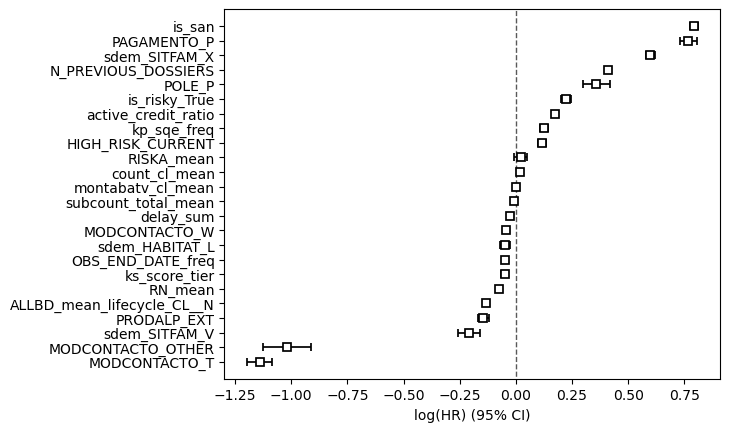

In [46]:
# Ver a importância das variáveis
cph.plot()

In [47]:
#Prever risco de churn
risk_scores = cph.predict_partial_hazard(X_test)

KeyError: "['kp_sqe_freq', 'OBS_END_DATE_freq', 'POLE_P', 'PAGAMENTO_P', 'is_risky_True', 'PRODALP_EXT', 'MODCONTACTO_OTHER', 'MODCONTACTO_T', 'MODCONTACTO_W', 'sdem_HABITAT_L', 'sdem_SITFAM_V', 'sdem_SITFAM_X'] not in index"

In [ ]:
#Prever survival probability
survival = cph.predict_survival_function(X_test.iloc[:5])

In [ ]:
# Métrica para Survival Models
cph.score(train, scoring_method="concordance_index")